In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [7]:
news = pd.read_csv("../data/raw/newsData/raw_analyst_ratings.csv")

stock = pd.read_csv("../data/raw/yfinance_data/Data/AAPL.csv")

In [8]:
news["date"] = pd.to_datetime(news["date"], errors="coerce")

stock["Date"] = pd.to_datetime(stock["Date"])

news = news.dropna(subset=["date"])

news["date_only"] = news["date"].dt.date

stock["date_only"] = stock["Date"].dt.date

In [9]:
analyzer = SentimentIntensityAnalyzer()

In [10]:
news["sentiment_score"] = news["headline"].astype(str).apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

In [11]:
daily_sentiment = news.groupby("date_only")["sentiment_score"].mean().reset_index()

In [12]:
stock["daily_return"] = stock["Close"].pct_change() * 100

In [13]:
merged = pd.merge(
    daily_sentiment,
    stock[["date_only", "daily_return"]],
    on="date_only",
    how="inner"
)

merged.head()

,date_only,sentiment_score,daily_return
0,2011-04-27,0.000000,-0.077042
1,2011-04-28,0.125000,-0.971032
2,2011-04-29,0.367550,0.974822
3,2011-05-02,0.136444,-1.099651
4,2011-05-03,0.000000,0.554465


In [14]:
correlation = merged["sentiment_score"].corr(merged["daily_return"])

print("Pearson Correlation:", correlation)

Pearson Correlation: 0.048285896458491774


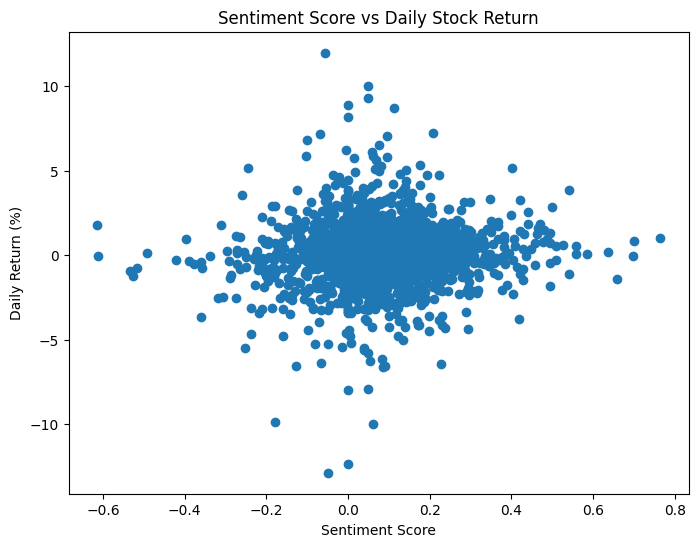

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    merged["sentiment_score"],
    merged["daily_return"]
)

plt.title("Sentiment Score vs Daily Stock Return")
plt.xlabel("Sentiment Score")
plt.ylabel("Daily Return (%)")

plt.show()

In [16]:
def classify_sentiment(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

merged["sentiment_category"] = merged["sentiment_score"].apply(classify_sentiment)

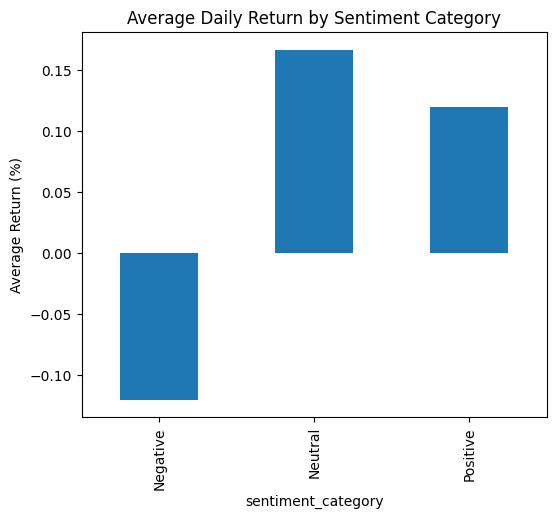

In [17]:
category_returns = merged.groupby("sentiment_category")["daily_return"].mean()

plt.figure(figsize=(6,5))

category_returns.plot(kind="bar")

plt.title("Average Daily Return by Sentiment Category")
plt.ylabel("Average Return (%)")

plt.show()

## Correlation Interpretation

The Pearson correlation coefficient between news sentiment scores and daily stock returns was approximately **0.048**. This indicates a weak positive relationship between headline sentiment and short-term stock price movement.

Although the correlation is small, the result suggests that positive news sentiment may contribute slightly to favorable market behavior. However, stock prices are influenced by many additional factors, including macroeconomic conditions, company fundamentals, investor psychology, and broader market trends.

The findings imply that sentiment analysis alone is not sufficient for accurate stock prediction, but it may provide useful supplementary signals when combined with technical indicators such as RSI, MACD, and moving averages.

These results are consistent with real-world financial markets, where sentiment contributes to market dynamics but rarely acts as a single dominant predictor.
